In [1]:
# the problem with backpropagation is leaky abstraction.
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

/Users/yuxinliu/anaconda3/lib/python3.11/site-packages/torch/utils/_pytree.py:185: FutureWarning: optree is installed but the version is too old to support PyTorch Dynamo in C++ pytree. C++ pytree support is disabled. Please consider upgrading optree using `python3 -m pip install --upgrade 'optree>=0.13.0'`.
  warnings.warn(


In [2]:
# read in all the words
words = open('names.txt', 'r').read().splitlines()
print(len(words))
print(max(len(w) for w in words))
words[:8]

32033
15


['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [3]:
# build the vocabulary of characters and mappings to/from integers
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
vocab_size = len(itos)
print(itos)
print(vocab_size)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}
27


In [4]:
# build the dataset
block_size = 3 # context length: how many characters do we take to predict the next one?
def build_dataset(words):
    X, Y = [], []
    for w in words:
        context = [0] * block_size
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix] # crop and append
    X = torch.tensor(X)
    Y = torch.tensor(Y)
    print(X.shape, Y.shape)
    return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr, Ytr = build_dataset(words[:n1]) # 80%
Xdev, Ydev = build_dataset(words[n1:n2]) # 10%
Xte, Yte = build_dataset(words[n2:]) # 10%

torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


In [15]:
# utility function we will use later when comparing manual gradients to Pytorch gradients
def cmp(s, dt, t):
    ex = torch.all(dt == t.grad).item()
    app = torch.allclose(dt, t.grad)
    maxdiff = (dt - t.grad).abs().max().item()
    print(f'{s:15s} | exact: {str(ex):5s} | approximate: {str(app):5s} | maxdiff: {maxdiff}')

In [6]:
n_embd = 10  # the dimensionality of the character embedding vectors
n_hidden = 200  # the number of neurons in the hidden layer

g = torch.Generator().manual_seed(2147483647)  # for reproducibility
C = torch.randn((vocab_size, n_embd), generator=g)  # the embedding table
# Layer 1
W1 = torch.randn((n_embd * block_size, n_hidden), generator=g) * (5 / 3) / (n_embd * block_size) ** 0.5 # gain for tanh
b1 = torch.randn(n_hidden, generator=g) * 0.1 # useless bias, but we want to test the backprop through it
# Layer 2
W2 = torch.randn((n_hidden, vocab_size), generator=g) * 0.1
b2 = torch.randn(vocab_size, generator=g) * 0.1
# BatchNorm parameters
bngain = torch.ones((1, n_hidden)) * 0.1 + 1.0
bnbias = torch.zeros((1, n_hidden)) * 0.1
# bnmean_running = torch.zeros((1, n_hidden))
# bnstd_running = torch.ones((1, n_hidden))

parameters = [C, W1, b1, W2, b2, bngain, bnbias]
print(sum(p.nelement() for p in parameters))  # number of parameters in total
for p in parameters:
    p.requires_grad = True

12297


In [7]:
batch_size = 32
n = batch_size
# construct a minibatch
ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
Xb, Yb = Xtr[ix], Ytr[ix]

In [24]:
# forward pass, "chunkated" into smaller steps that are possible to backward one at a time
emb = C[Xb]  # embed the characters into vectors
embcat = emb.view(emb.shape[0], -1)  # concatenate the vectors
# Linear layer 1
hprebn = embcat @ W1 + b1  # hidden layer pre-activation
# BatchNorm layer
bnmeani = 1/n * hprebn.sum(0, keepdim=True) 
bndiff = hprebn - bnmeani
bndiff2 = bndiff ** 2
bnvar = 1/(n-1) * bndiff2.sum(0, keepdim=True) # note: Bessel's correction (dividing by n-1, not n)
bnvar_inv = (bnvar + 1e-5) ** -0.5
bnraw = bndiff * bnvar_inv
hpreact = bngain * bnraw + bnbias
# Non-linearity
h = torch.tanh(hpreact) # hidden layer
# Linear layer 2
logits = h @ W2 + b2 # output layer
# cross entropy loss (same as F.cross_entropy(logits, Yb))
logit_maxes = logits.max(1, keepdim=True).values
norm_logits = logits - logit_maxes # subtract max for numerical stability
counts = norm_logits.exp()
counts_sum = counts.sum(1, keepdim=True)
counts_sum_inv = counts_sum ** -1 # if I use (1.0 / counts_sum) instead then I can't get backprop to be bit exact...
probs = counts * counts_sum_inv
logprobs = probs.log()
loss = -logprobs[range(n), Yb].mean()

# Pytorch backward pass
for p in parameters:
    p.grad = None
for t in [logprobs, probs, counts_sum_inv, counts_sum, counts, norm_logits, logits, logit_maxes, h, hpreact, bnraw, bnvar_inv, bnvar, bndiff2, bndiff, bnmeani, hprebn, embcat, emb]:
    t.retain_grad()
loss.backward()
loss

tensor(3.8279, grad_fn=<NegBackward0>)

In [25]:
Yb

tensor([ 1, 12,  0,  5,  9, 18,  9, 16,  1,  0,  0,  1,  0,  0, 14, 12,  0,  0,
         0,  8, 25,  5,  0, 20, 19, 15, 12, 22, 22,  2, 21, 18])

In [26]:
logprobs.shape

torch.Size([32, 27])

In [27]:
logprobs

tensor([[-4.4737, -1.5997, -4.0965, -3.4163, -2.8133, -4.0841, -4.6294, -4.3522,
         -3.4315, -3.8062, -2.8183, -4.9644, -3.8716, -5.2169, -3.8951, -3.9360,
         -3.6961, -5.1706, -6.1773, -4.1282, -1.9407, -3.1552, -2.5953, -4.3083,
         -5.5041, -2.8096, -2.7644],
        [-2.9138, -3.2064, -3.7923, -3.3294, -3.3902, -4.3600, -4.8044, -3.7086,
         -2.5350, -3.3419, -3.7918, -5.3781, -4.0272, -2.8782, -4.6864, -3.2369,
         -3.8677, -3.7333, -2.4258, -2.9420, -3.1745, -4.1116, -3.1403, -2.8597,
         -2.8388, -5.0339, -2.3690],
        [-3.7484, -3.3985, -2.4626, -4.2053, -3.7723, -3.5940, -3.1350, -3.3070,
         -3.0667, -2.5784, -2.7553, -4.6368, -4.3291, -4.5310, -2.3343, -1.9610,
         -4.8877, -3.0120, -2.7876, -5.5230, -3.6382, -4.2432, -4.2182, -5.7343,
         -3.4217, -3.7083, -4.0801],
        [-3.9838, -2.4010, -2.7263, -2.3265, -3.9493, -3.6299, -3.8739, -3.3855,
         -3.5099, -4.8184, -2.9144, -2.9181, -3.7459, -3.8523, -4.5294, -3.1763

In [28]:
logprobs[range(n), Yb]

tensor([-1.5997, -4.0272, -3.7484, -3.6299, -3.3076, -4.8307, -5.1132, -3.9004,
        -3.6930, -4.7350, -3.7821, -4.3303, -4.6160, -3.4832, -4.9639, -3.6120,
        -5.1593, -3.8163, -4.4858, -2.4303, -3.4927, -5.2744, -2.4229, -4.0030,
        -3.6568, -2.7276, -5.0097, -3.2933, -4.8807, -2.6652, -2.7636, -3.0399],
       grad_fn=<IndexBackward0>)

In [29]:
# loss = -(a + b + c)/3
# dloss/da = -1/n

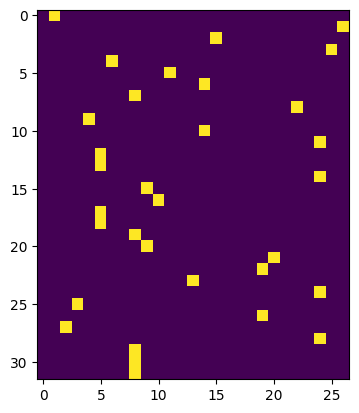

In [38]:
plt.imshow(F.one_hot(logits.max(1).indices, num_classes=logits.shape[1]))

In [37]:
print(emb.shape, C.shape, Xb.shape)
print(Xb[:5])

torch.Size([32, 3, 10]) torch.Size([27, 10]) torch.Size([32, 3])
tensor([[ 4,  5, 23],
        [18, 14, 21],
        [12, 12, 25],
        [ 5,  5,  3],
        [ 5, 12,  5]])


In [39]:
# Exercise 1: backprop through the whole thing manually,
# backprop through exactly all of the variables
# as they are defined in the forward pass above, one by one
dlogprobs = torch.zeros_like(logprobs)
dlogprobs[range(n), Yb] = -1.0/n
dprobs = (1.0 / probs) * dlogprobs
dcounts_sum_inv = (counts * dprobs).sum(1, keepdim=True)
dcounts = counts_sum_inv * dprobs
dcounts_sum = (-counts_sum ** -2) * dcounts_sum_inv
dcounts += torch.ones_like(counts) * dcounts_sum
dnorm_logits = counts * dcounts
dlogits = dnorm_logits.clone()
dlogit_maxes = (-dnorm_logits).sum(1, keepdim=True)
dlogits += F.one_hot(logits.max(1).indices, num_classes=logits.shape[1]) * dlogit_maxes
dh = dlogits @ W2.T
dW2 = h.T @ dlogits
db2 = dlogits.sum(0)
dhpreact = (1 - h ** 2) * dh
dbngain = (bnraw * dhpreact).sum(0, keepdim=True)
dbnraw = bngain * dhpreact
dbnbias = dhpreact.sum(0, keepdim=True)
dbndiff = bnvar_inv * dbnraw
dbnvar_inv = (bndiff * dbnraw).sum(0, keepdim=True)
dbnvar = (-0.5 * (bnvar + 1e-5) ** -1.5) * dbnvar_inv
dbndiff2 = (1.0 / (n-1) * torch.ones_like(bndiff2))*dbnvar
dbndiff += (2 * bndiff) * dbndiff2
dhprebn = dbndiff.clone()
dbnmeani = (-dbndiff).sum(0)
dhprebn += 1.0/n * (torch.ones_like(hprebn) * dbnmeani)
dembcat = dhprebn @ W1.T
dW1 = embcat.T @ dhprebn
db1 = dhprebn.sum(0)
demb = dembcat.view(emb.shape)
dC = torch.zeros_like(C)
for k in range(Xb.shape[0]):
    for j in range(Xb.shape[1]):
        ix = Xb[k, j]
        dC[ix] += demb[k,j]

cmp('logprobs', dlogprobs, logprobs)
cmp('probs', dprobs, probs)
cmp('counts_sum_inv', dcounts_sum_inv, counts_sum_inv)
cmp('counts_sum', dcounts_sum, counts_sum)
cmp('counts', dcounts, counts)
cmp('norm_logits', dnorm_logits, norm_logits)
cmp('logit_maxes', dlogit_maxes, logit_maxes)
cmp('h', dh, h)
cmp('W2', dW2, W2)
cmp('b2', db2, b2)
cmp('hpreact', dhpreact, hpreact)
cmp('bngain', dbngain, bngain)
cmp('bnbias', dbnbias, bnbias)
cmp('bnraw', dbnraw, bnraw)
cmp('bnvar_inv', dbnvar_inv, bnvar_inv)
cmp('bnvar', dbnvar, bnvar)
cmp('bndiff2', dbndiff2, bndiff2)
cmp('bndiff', dbndiff, bndiff)
cmp('bnmeani', dbnmeani, bnmeani)
cmp('hprebn', dhprebn, hprebn)
cmp('embcat', dembcat, embcat)
cmp('W1', dW1, W1)
cmp('b1', db1, b1)
cmp('emb', demb, emb)
cmp('C', dC, C)

logprobs        | exact: True  | approximate: True  | maxdiff: 0.0
probs           | exact: True  | approximate: True  | maxdiff: 0.0
counts_sum_inv  | exact: True  | approximate: True  | maxdiff: 0.0
counts_sum      | exact: True  | approximate: True  | maxdiff: 0.0
counts          | exact: True  | approximate: True  | maxdiff: 0.0
norm_logits     | exact: True  | approximate: True  | maxdiff: 0.0
logit_maxes     | exact: True  | approximate: True  | maxdiff: 0.0
h               | exact: True  | approximate: True  | maxdiff: 0.0
W2              | exact: True  | approximate: True  | maxdiff: 0.0
b2              | exact: True  | approximate: True  | maxdiff: 0.0
hpreact         | exact: True  | approximate: True  | maxdiff: 0.0
bngain          | exact: True  | approximate: True  | maxdiff: 0.0
bnbias          | exact: True  | approximate: True  | maxdiff: 0.0
bnraw           | exact: True  | approximate: True  | maxdiff: 0.0
bnvar_inv       | exact: True  | approximate: True  | maxdiff:

In [40]:
# Exercise 2: backprop through cross_entropy but all in one go
# to complete this challenge look at the mathematical expression of the loss,
# take the derivation, simplify it, and just write it out

# forward pass

# before:
# logit_maxes = logits.max(1, keepdim=True).values
# norm_logits = logits - logit_maxes # subtract max for numerical stability
# counts = norm_logits.exp()
# counts_sum = counts.sum(1, keepdim=True)
# counts_sum_inv = counts_sum ** -1 # if I use (1.0 / counts_sum) instead then I can't get backprop to be bit exact...
# probs = counts * counts_sum_inv
# logprobs = probs.log()
# loss = -logprobs[range(n), Yb].mean()

# now:
loss_fast = F.cross_entropy(logits, Yb)
print(loss_fast.item(), 'diff:', (loss_fast - loss).item())

3.827936887741089 diff: -2.384185791015625e-07


In [41]:
# backward pass
dlogits = F.softmax(logits, dim=1)
dlogits[range(n), Yb] -= 1
dlogits /= n

cmp('logits', dlogits, logits) # I can only get approximate to be true, my maxdiff is 6e-9

logits          | exact: False | approximate: True  | maxdiff: 5.122274160385132e-09


In [42]:
logits.shape, Yb.shape

(torch.Size([32, 27]), torch.Size([32]))

In [43]:
F.softmax(logits, 1)[0]

tensor([0.0114, 0.2019, 0.0166, 0.0328, 0.0600, 0.0168, 0.0098, 0.0129, 0.0323,
        0.0222, 0.0597, 0.0070, 0.0208, 0.0054, 0.0203, 0.0195, 0.0248, 0.0057,
        0.0021, 0.0161, 0.1436, 0.0426, 0.0746, 0.0135, 0.0041, 0.0602, 0.0630],
       grad_fn=<SelectBackward0>)

In [44]:
dlogits[0]*n

tensor([ 0.0114, -0.7981,  0.0166,  0.0328,  0.0600,  0.0168,  0.0098,  0.0129,
         0.0323,  0.0222,  0.0597,  0.0070,  0.0208,  0.0054,  0.0203,  0.0195,
         0.0248,  0.0057,  0.0021,  0.0161,  0.1436,  0.0426,  0.0746,  0.0135,
         0.0041,  0.0602,  0.0630], grad_fn=<MulBackward0>)

In [45]:
dlogits[0].sum()

tensor(1.1642e-09, grad_fn=<SumBackward0>)

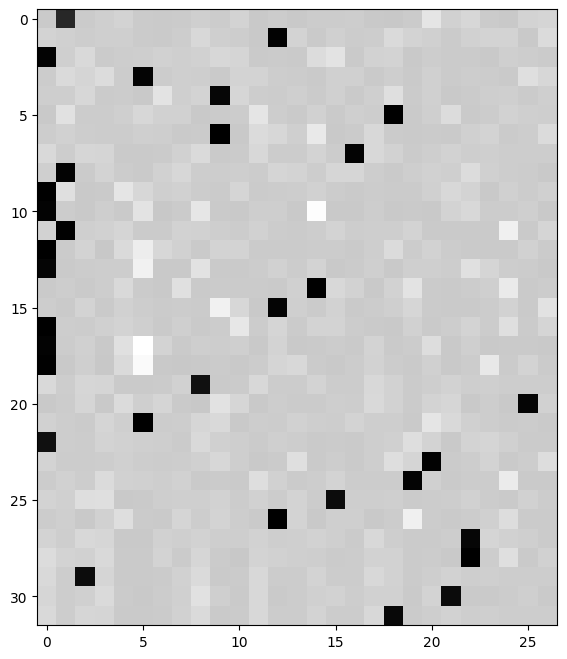

In [46]:
plt.figure(figsize=(8, 8))
plt.imshow(dlogits.detach(), cmap='gray')

In [47]:
# Exercise 3: backprop through batchnorm but all in one go
# to complete this challenge look at the mathematical expression of the output of batchnorm,
# take the derivation w.r.t. its input, simplify the expression, and just write it out

# forward pass
# before:
# bnmeani = 1/n * hprebn.sum(0, keepdim=True)
# bndiff = hprebn - bnmeani
# bndiff2 = bndiff ** 2
# bnvar = 1/(n-1) * bndiff2.sum(0, keepdim=True) # note: Bessel's correction (dividing by n-1, not n)
# bnvar_inv = (bnvar + 1e-5) ** -0.5
# bnraw = bndiff * bnvar_inv
# hpreact = bngain * bnraw + bnbias

# now:
hpreact_fast = bngain * (hprebn - hprebn.mean(0, keepdim=True)) / torch.sqrt(hprebn.var(0, keepdim=True, unbiased=True) + 1e-5) + bnbias
print('max diff:', (hpreact_fast - hpreact).abs().max())

max diff: tensor(7.1526e-07, grad_fn=<MaxBackward1>)


In [48]:
# backward pass

# before we had:
# dbnraw = bngain * dhpreact
# dbndiff = bnvar_inv * dbnraw
# dbnvar_inv = (bndiff * dbnraw).sum(0, keepdim=True)
# dbnvar = (-0.5 * (bnvar + 1e-5) ** -1.5) * dbnvar_inv
# dbndiff2 = (1.0 / (n-1) * torch.ones_like(bndiff2))*dbnvar
# dbndiff += (2 * bndiff) * dbndiff2
# dhprebn = dbndiff.clone()
# dbnmeani = (-dbndiff).sum(0)
# dhprebn += 1.0/n * (torch.ones_like(hprebn) * dbnmeani)

# calculate dhprebn given dhpreact (i.e. backprop through the batchnorm)
# (you'll also need to use some of the variables from the forward pass up above)
dhprebn = bngain * bnvar_inv/n * (n * dhpreact - dhpreact.sum(0) - n/(n-1) * bnraw * (dhpreact * bnraw).sum(0))
cmp('hprebn', dhprebn, hprebn) # I can only get approximate to be true, my maxdiff is 9e-10

hprebn          | exact: False | approximate: True  | maxdiff: 9.313225746154785e-10


In [50]:
dhprebn.shape, bngain.shape, bnvar_inv.shape, bnraw.shape, dbnraw.sum(0).shape

(torch.Size([32, 200]),
 torch.Size([1, 200]),
 torch.Size([1, 200]),
 torch.Size([32, 200]),
 torch.Size([200]))

In [52]:
# Exercise 4: putting it all together!
# Train the MLP neural net with your own backward pass

# init
n_embd = 10  # the dimensionality of the character embedding vectors
n_hidden = 200  # the number of neurons in the hidden layer

g = torch.Generator().manual_seed(2147483647)  # for reproducibility
C = torch.randn((vocab_size, n_embd), generator=g)  # the embedding table
# Layer 1
W1 = torch.randn((n_embd * block_size, n_hidden), generator=g) * (5 / 3) / (n_embd * block_size) ** 0.5 # gain for tanh
b1 = torch.randn(n_hidden, generator=g) * 0.1 # useless bias, but we want to test the backprop through it
# Layer 2
W2 = torch.randn((n_hidden, vocab_size), generator=g) * 0.1
b2 = torch.randn(vocab_size, generator=g) * 0.1
# BatchNorm parameters
bngain = torch.ones((1, n_hidden)) * 0.1 + 1.0
bnbias = torch.zeros((1, n_hidden)) * 0.1

parameters = [C, W1, b1, W2, b2, bngain, bnbias]
print(sum(p.nelement() for p in parameters))  # number of parameters in total
for p in parameters:
    p.requires_grad = True

# same optimization as last time
max_steps = 200000
batch_size = 32
lossi = []
n = batch_size # convenience

# use this context manager for efficiency once your backward pass is written
with torch.no_grad():

    # kick off optimization
    for i in range(max_steps):
        
        # minibatch construct
        ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
        Xb, Yb = Xtr[ix], Ytr[ix] # batch X and Y
        
        # forward pass
        emb = C[Xb] # embed the characters into vectors
        embcat = emb.view(emb.shape[0], -1) # concatenate the vectors
        # Linear layer
        hprebn = embcat @ W1 + b1 # hidden layer pre-activation
        # BatchNorm layer
        bnmean = hprebn.mean(0, keepdim=True)
        bnvar = hprebn.var(0, keepdim=True, unbiased=True)
        bnvar_inv = (bnvar + 1e-5) ** -0.5
        bnraw = (hprebn - bnmean) * bnvar_inv
        hpreact = bngain * bnraw + bnbias
        # Non-linearity
        h = torch.tanh(hpreact) # hidden layer 
        logits = h @ W2 + b2 # output layer
        loss = F.cross_entropy(logits, Yb) # loss function
        
        # backward pass
        for p in parameters:
            p.grad = None
        # loss.backward()
        
        # manual backprop!
        dlogits = F.softmax(logits, dim=1)
        dlogits[range(n), Yb] -= 1
        dlogits /= n
        # 2nd layer backprop
        dh = dlogits @ W2.T
        dW2 = h.T @ dlogits
        db2 = dlogits.sum(0)
        # tanh
        dhpreact = (1.0 - h ** 2) * dh
        # batchnorm backprop
        dbngain = (bnraw * dhpreact).sum(0, keepdim=True)
        dbnbias = dhpreact.sum(0, keepdim=True)
        dbprebn = bngain * bnvar_inv/n * (n * dhpreact - dhpreact.sum(0) - n/(n-1) * bnraw * (dhpreact * bnraw).sum(0))
        # 1st layer
        dembcat = dbprebn @ W1.T
        dW1 = embcat.T @ dbprebn
        db1 = dbprebn.sum(0)
        # embedding
        demb = dembcat.view(emb.shape)
        dC = torch.zeros_like(C)
        for k in range(Xb.shape[0]):
            for j in range(Xb.shape[1]):
                ix = Xb[k, j]
                dC[ix] += demb[k,j]
        grads = [dC, dW1, db1, dW2, db2, dbngain, dbnbias]
        # update
        lr = 0.1 if i < 100000 else 0.01 # step learning rate decay
        for p, grad in zip(parameters, grads):
            p.data += -lr * grad
            #p.data += -lr * p.grad
        
        # track stats
        if i % 10000 == 0:
            print(f'{i:7d}/{max_steps}: {loss.item():.4f}')
        lossi.append(loss.log10().item())
            
        # if i >= 1000:
        #     break
        
    # break # AFTER_DEBUG: would take out obviously to run full optimization

12297
      0/200000: 3.8279
  10000/200000: 2.1609
  20000/200000: 2.4227
  30000/200000: 2.4362
  40000/200000: 2.0088
  50000/200000: 2.4084
  60000/200000: 2.4508
  70000/200000: 2.1090
  80000/200000: 2.3592
  90000/200000: 2.2353
 100000/200000: 1.9750
 110000/200000: 2.3438
 120000/200000: 2.0156
 130000/200000: 2.4772
 140000/200000: 2.3107
 150000/200000: 2.1108
 160000/200000: 1.9497
 170000/200000: 1.8004
 180000/200000: 2.0284
 190000/200000: 1.8848


In [53]:
# useful for checking your gradients
for p,g in zip(parameters, grads):
    cmp(str(tuple(p.shape)), g, p) # should p.grad = grad in loop

TypeError: all() received an invalid combination of arguments - got (bool), but expected one of:
 * (Tensor input, *, Tensor out = None)
 * (Tensor input, tuple of ints dim = None, bool keepdim = False, *, Tensor out = None)
 * (Tensor input, int dim, bool keepdim = False, *, Tensor out = None)
 * (Tensor input, name dim, bool keepdim = False, *, Tensor out = None)


In [54]:
# calibrate the batch norm at the end of training
with torch.no_grad():
    # pass the training set through
    emb = C[Xtr]
    embcat = emb.view(emb.shape[0], -1)
    hpreact = embcat @ W1 + b1
    # measure the mean/std over the entire training set
    bnmean = hpreact.mean(0, keepdim=True)
    bnvar = hpreact.var(0, keepdim=True, unbiased=True)

In [55]:
@torch.no_grad() # this decorator disables gradient tracking
def split_loss(split):
    x, y = {
        'train': (Xtr, Ytr),
        'val': (Xdev, Ydev),
        'test': (Xte, Yte),
    }[split]
    emb = C[x] # (N, block_size, n_embd)
    embcat = emb.view(emb.shape[0], -1) # concat into (N, block_size*n_embd)
    hpreact = embcat @ W1 + b1
    hpreact = bngain * (hpreact - bnmean) / (bnvar + 1e-5) ** -0.5 + bnbias
    h = torch.tanh(hpreact) # (N, n_hidden)
    logits = h @ W2 + b2 # (N, vocab_size)
    loss = F.cross_entropy(logits, y)
    print(split, loss.item())
    
split_loss('train')
split_loss('val')

train 2.6436338424682617
val 2.7023117542266846


In [56]:
# sample from the model
g = torch.Generator().manual_seed(2147483647)

for _ in range(20):
    out = []
    context = [0] * block_size # initialize with all ...
    while True:
        # forward pass the neural net
        emb = C[torch.tensor([context])] # (1, block_size, n_embd)
        embcat = emb.view(emb.shape[0], -1) # (N, block_size*n_embd)
        hpreact = embcat @ W1 + b1
        hpreact = bngain * (hpreact - bnmean) / (bnvar + 1e-5) ** -0.5 + bnbias
        h = torch.tanh(hpreact) # (N, n_hidden)
        logits = h @ W2 + b2 # (N, vocab_size)
        probs = F.softmax(logits, dim=1)
        # sample from the distribution
        ix = torch.multinomial(probs, num_samples=1, generator=g).item()
        context = context[1:] + [ix] # crop and append
        out.append(ix)
        # if we sample the special '.' token, break
        if ix == 0:
            break
    print(''.join(itos[i] for i in out)) # decode and print the generated word

cesie.
couller.
jochukwu.
brooklynn.
corlynn.
jakoda.
skylynn.
jaxson.
jazson.
jaxque.
kashtte.
jakaylena.
sadelyn.
bowdndreolspiah.
juliotalexsufaudric.
jasley.
kamilly.
juliennek.
jumerestiffrey.
kaika.
